In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
import numpy as np

c:\Users\rafae\Codigo\federated_learning\flower-tutorial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Modelo CNN para imágenes médicas
# Definición de la arquitectura de la red
class MedicalCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3, weight_decay=1e-4):
        super(MedicalCNN, self).__init__()
        
        self.weight_decay = weight_decay
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),  # Añadido Dropout2d después de la primera capa
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),  # Añadido Dropout2d después de la segunda capa
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)  # Incrementado el dropout
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.BatchNorm1d(512),  # Añadido BatchNorm
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),  # Capa adicional con menos neuronas
            nn.BatchNorm1d(256),  # Añadido BatchNorm
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
    def get_l2_regularization_loss(self):
        """Calcula la pérdida de regularización L2 para los parámetros del modelo"""
        l2_loss = 0.0
        for param in self.parameters():
            l2_loss += torch.sum(param ** 2)
        return self.weight_decay * l2_loss

In [3]:
# Implementación de la clase IMGDataset
class IMGDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
        self.labels = hf_dataset['label']  # Guardar las etiquetas para facilitar el balanceo
        
    def __len__(self):
        return len(self.dataset)
        
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [4]:
# Configuración de transformaciones
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Conversión a escala de grises
    transforms.Resize((224, 224)),                # Redimensionar a 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [5]:
# Función de entrenamiento
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Añadir regularización L2
            l2_loss = model.get_l2_regularization_loss()
            total_loss = loss + l2_loss

            total_loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validación
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\n')
    
    # Visualización de resultados
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


In [6]:
# Cargar dataset y aplicar transformaciones
dataset = load_dataset('hf-vision/chest-xray-pneumonia')

# Número de clases en el dataset   
num_classes = len(set(dataset['train']['label']))  


# Función para obtener un sampler balanceado
def get_balanced_sampler(dataset):
    # Obtener las etiquetas dependiendo del tipo de dataset
    if isinstance(dataset, torch.utils.data.Subset):
        # Para un subset creado con random_split
        indices = dataset.indices
        # Acceder al dataset original y obtener las etiquetas para estos índices
        original_dataset = dataset.dataset
        if hasattr(original_dataset, 'label'):
            # Si el dataset tiene un atributo label directo
            labels = [original_dataset.label[i] for i in indices]
        else:
            # Si es nuestro IMGDataset que envuelve un dataset de HF
            labels = [original_dataset.labels[i] if hasattr(original_dataset, 'labels') 
                     else original_dataset.dataset['label'][i] for i in indices]
    else:
        # Para nuestro IMGDataset directamente
        if hasattr(dataset, 'labels'):
            labels = dataset.labels
        else:
            # Asumiendo que dataset tiene un atributo 'dataset' que es el dataset de HF
            labels = dataset.dataset['label']
    
    # Convertir a numpy array para facilitar el cálculo
    labels = np.array(labels)
    
    # Calcular el recuento de clases
    class_counts = np.bincount(labels)
    print(f"Distribución de clases: {class_counts}")
    
    # Calcular pesos: 1/frecuencia de la clase
    class_weights = 1. / class_counts
    
    # Asignar peso a cada muestra según su clase
    weights = class_weights[labels]
    
    # Crear el sampler
    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(labels),
        replacement=True
    )
    
    return sampler

# Verificar si el dataset ya viene con splits predefinidos
if 'train' in dataset and 'validation' in dataset:
    # Usar los splits predefinidos
    train_dataset = IMGDataset(dataset['train'], transform=transform)
    val_dataset = IMGDataset(dataset['validation'], transform=transform)
else:
    # Si solo hay un split o ninguno está definido como 'validation'
    # Dividir manualmente el dataset (asumiendo que 'train' existe)
    
    full_dataset = IMGDataset(dataset['train'], transform=transform)
    
    # Definir tamaños para train y validation (80% - 20%)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Verificar si el dataset ya viene con splits predefinidos
train_dataset = IMGDataset(dataset['train'], transform=transform)
val_dataset = IMGDataset(dataset['validation'], transform=transform)
test_dataset = IMGDataset(dataset['test'], transform=transform)

# Obtener un sampler balanceado para el conjunto de entrenamiento
train_sampler = get_balanced_sampler(train_dataset)

# Crear los DataLoaders
batch_size = 32  # Ajusta según tus necesidades y recursos

# Para el conjunto de entrenamiento, usamos el sampler balanceado
# Nota: cuando usamos un sampler personalizado, debemos establecer shuffle=False
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=train_sampler,  # Usamos el sampler balanceado en lugar de shuffle
    #num_workers=4
)

# Para el conjunto de validación, no es necesario balancear
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    #num_workers=4
)

# Para el conjunto de test (si es necesario)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    #num_workers=4
)

# Función de preprocesamiento para extraer imagen y etiqueta
def preprocess(batch):
    images = [transform(img) for img in batch['image']]  # Aplica las transformaciones a cada imagen
    labels = batch['label']                              # Toma las etiquetas
    return torch.stack(images), torch.tensor(labels)


Distribución de clases: [1341 3875]


Epoch 1/30:
Train Loss: 0.2589, Train Acc: 89.17%
Val Loss: 0.3969, Val Acc: 81.25%

Epoch 2/30:
Train Loss: 0.1503, Train Acc: 94.34%
Val Loss: 0.4226, Val Acc: 75.00%

Epoch 3/30:
Train Loss: 0.1419, Train Acc: 94.63%
Val Loss: 0.1219, Val Acc: 100.00%

Epoch 4/30:
Train Loss: 0.1402, Train Acc: 95.05%
Val Loss: 0.3248, Val Acc: 87.50%

Epoch 5/30:
Train Loss: 0.1481, Train Acc: 94.71%
Val Loss: 0.2165, Val Acc: 93.75%

Epoch 6/30:
Train Loss: 0.1581, Train Acc: 94.48%
Val Loss: 0.2410, Val Acc: 93.75%

Epoch 7/30:
Train Loss: 0.1392, Train Acc: 94.50%
Val Loss: 0.3027, Val Acc: 87.50%

Epoch 8/30:
Train Loss: 0.1438, Train Acc: 94.61%
Val Loss: 0.2849, Val Acc: 87.50%

Epoch 9/30:
Train Loss: 0.1327, Train Acc: 94.75%
Val Loss: 0.1733, Val Acc: 93.75%

Epoch 10/30:
Train Loss: 0.1441, Train Acc: 94.48%
Val Loss: 0.5238, Val Acc: 75.00%

Epoch 11/30:
Train Loss: 0.1434, Train Acc: 94.46%
Val Loss: 0.2585, Val Acc: 87.50%

Epoch 12/30:
Train Loss: 0.1480, Train Acc: 94.42%
Val Loss: 0

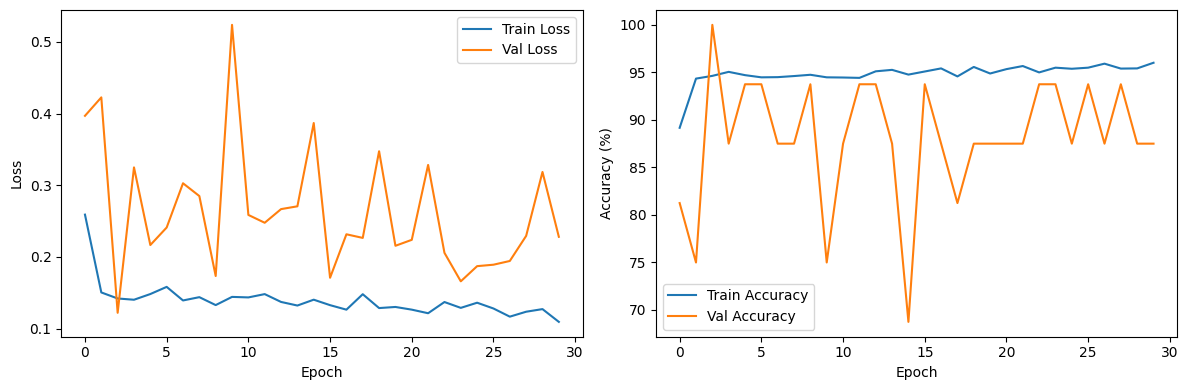

In [7]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.6, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 0.2207, Train Acc: 90.70%
Val Loss: 0.5799, Val Acc: 68.75%

Epoch 2/30:
Train Loss: 0.1315, Train Acc: 95.28%
Val Loss: 0.2101, Val Acc: 93.75%

Epoch 3/30:
Train Loss: 0.1120, Train Acc: 95.95%
Val Loss: 0.2715, Val Acc: 87.50%

Epoch 4/30:
Train Loss: 0.1225, Train Acc: 95.67%
Val Loss: 0.2559, Val Acc: 87.50%

Epoch 5/30:
Train Loss: 0.1288, Train Acc: 95.05%
Val Loss: 0.2471, Val Acc: 87.50%

Epoch 6/30:
Train Loss: 0.1265, Train Acc: 95.23%
Val Loss: 0.2628, Val Acc: 87.50%

Epoch 7/30:
Train Loss: 0.1237, Train Acc: 95.57%
Val Loss: 0.1580, Val Acc: 93.75%

Epoch 8/30:
Train Loss: 0.1219, Train Acc: 95.55%
Val Loss: 0.1884, Val Acc: 93.75%

Epoch 9/30:
Train Loss: 0.1232, Train Acc: 95.48%
Val Loss: 0.3046, Val Acc: 75.00%

Epoch 10/30:
Train Loss: 0.1137, Train Acc: 95.59%
Val Loss: 0.5130, Val Acc: 75.00%

Epoch 11/30:
Train Loss: 0.1361, Train Acc: 95.17%
Val Loss: 0.2288, Val Acc: 87.50%

Epoch 12/30:
Train Loss: 0.1288, Train Acc: 95.49%
Val Loss: 0.

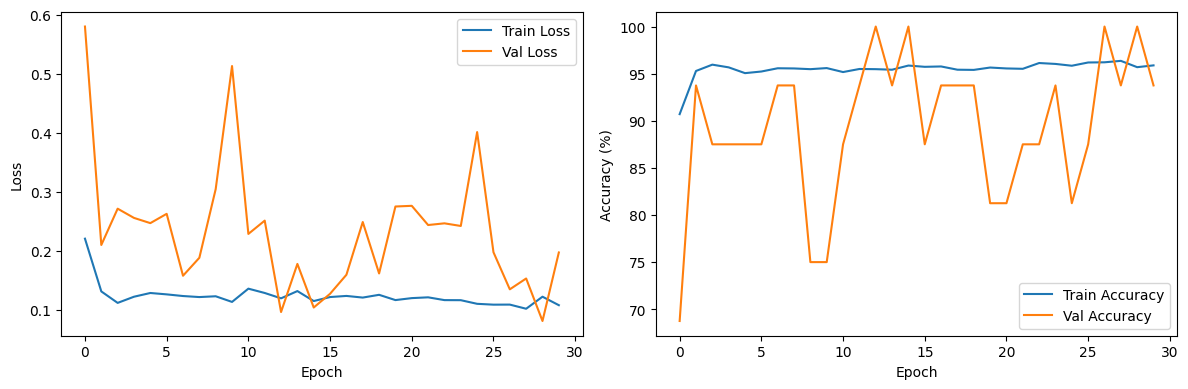

In [8]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.4, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 0.2511, Train Acc: 89.28%
Val Loss: 0.3170, Val Acc: 87.50%

Epoch 2/30:
Train Loss: 0.1424, Train Acc: 94.59%
Val Loss: 0.1214, Val Acc: 100.00%

Epoch 3/30:
Train Loss: 0.1117, Train Acc: 95.67%
Val Loss: 0.1365, Val Acc: 100.00%

Epoch 4/30:
Train Loss: 0.1166, Train Acc: 95.67%
Val Loss: 0.1585, Val Acc: 93.75%

Epoch 5/30:
Train Loss: 0.0945, Train Acc: 96.76%
Val Loss: 0.0840, Val Acc: 93.75%

Epoch 6/30:
Train Loss: 0.1014, Train Acc: 96.43%
Val Loss: 0.1246, Val Acc: 93.75%

Epoch 7/30:
Train Loss: 0.0973, Train Acc: 96.64%
Val Loss: 0.0999, Val Acc: 100.00%

Epoch 8/30:
Train Loss: 0.0844, Train Acc: 97.12%
Val Loss: 0.0989, Val Acc: 100.00%

Epoch 9/30:
Train Loss: 0.1002, Train Acc: 96.51%
Val Loss: 0.0926, Val Acc: 100.00%

Epoch 10/30:
Train Loss: 0.0932, Train Acc: 96.82%
Val Loss: 0.1520, Val Acc: 93.75%

Epoch 11/30:
Train Loss: 0.0909, Train Acc: 96.93%
Val Loss: 0.1605, Val Acc: 93.75%

Epoch 12/30:
Train Loss: 0.0838, Train Acc: 96.86%
Val Los

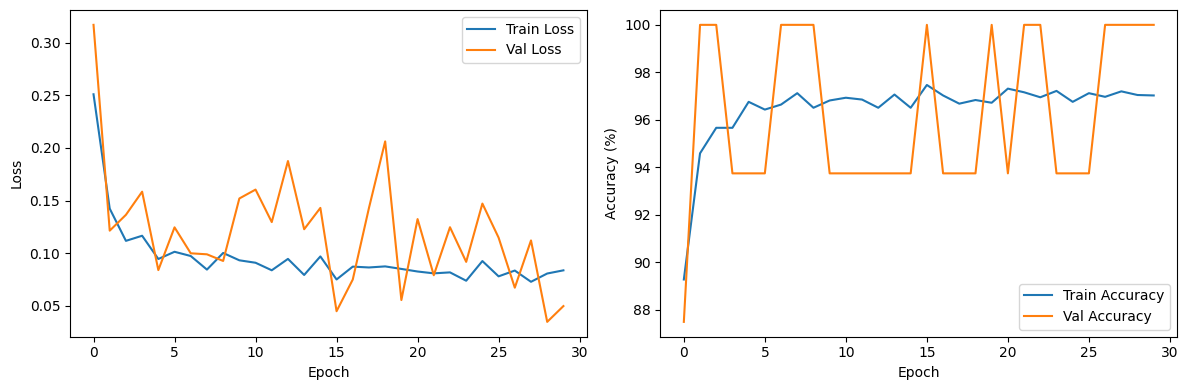

In [9]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.6, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 0.1961, Train Acc: 92.06%
Val Loss: 0.2568, Val Acc: 87.50%

Epoch 2/30:
Train Loss: 0.1315, Train Acc: 95.36%
Val Loss: 0.2256, Val Acc: 87.50%

Epoch 3/30:
Train Loss: 0.1293, Train Acc: 94.98%
Val Loss: 0.2906, Val Acc: 87.50%

Epoch 4/30:
Train Loss: 0.1183, Train Acc: 95.48%
Val Loss: 0.2110, Val Acc: 87.50%

Epoch 5/30:
Train Loss: 0.1106, Train Acc: 95.94%
Val Loss: 0.2287, Val Acc: 93.75%

Epoch 6/30:
Train Loss: 0.1138, Train Acc: 95.80%
Val Loss: 0.2408, Val Acc: 87.50%

Epoch 7/30:
Train Loss: 0.1308, Train Acc: 95.15%
Val Loss: 0.2469, Val Acc: 87.50%

Epoch 8/30:
Train Loss: 0.1120, Train Acc: 95.94%
Val Loss: 0.3228, Val Acc: 81.25%

Epoch 9/30:
Train Loss: 0.1147, Train Acc: 95.84%
Val Loss: 0.2041, Val Acc: 87.50%

Epoch 10/30:
Train Loss: 0.1075, Train Acc: 96.11%
Val Loss: 0.2229, Val Acc: 87.50%

Epoch 11/30:
Train Loss: 0.1281, Train Acc: 95.53%
Val Loss: 0.1632, Val Acc: 93.75%

Epoch 12/30:
Train Loss: 0.1107, Train Acc: 96.17%
Val Loss: 0.

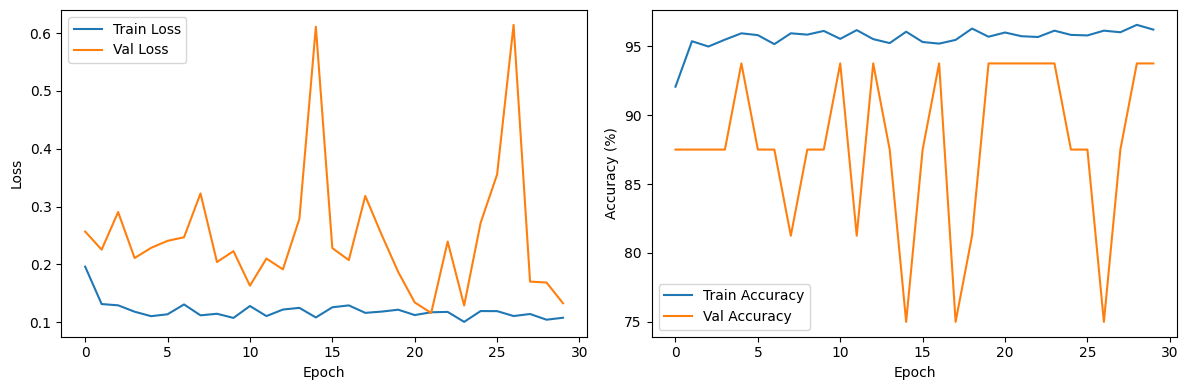

In [10]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.4, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 0.3198, Train Acc: 86.12%
Val Loss: 0.2832, Val Acc: 87.50%

Epoch 2/30:
Train Loss: 0.1833, Train Acc: 92.96%
Val Loss: 0.3134, Val Acc: 81.25%

Epoch 3/30:
Train Loss: 0.1857, Train Acc: 92.62%
Val Loss: 0.3034, Val Acc: 81.25%

Epoch 4/30:
Train Loss: 0.1872, Train Acc: 92.73%
Val Loss: 0.2769, Val Acc: 87.50%

Epoch 5/30:
Train Loss: 0.1893, Train Acc: 92.62%
Val Loss: 0.2577, Val Acc: 87.50%

Epoch 6/30:
Train Loss: 0.1828, Train Acc: 93.04%
Val Loss: 0.2943, Val Acc: 81.25%

Epoch 7/30:
Train Loss: 0.1822, Train Acc: 92.64%
Val Loss: 0.1935, Val Acc: 93.75%

Epoch 8/30:
Train Loss: 0.1765, Train Acc: 93.16%
Val Loss: 0.2469, Val Acc: 87.50%

Epoch 9/30:
Train Loss: 0.1700, Train Acc: 93.37%
Val Loss: 0.2962, Val Acc: 81.25%

Epoch 10/30:
Train Loss: 0.1696, Train Acc: 93.71%
Val Loss: 0.1987, Val Acc: 81.25%

Epoch 11/30:
Train Loss: 0.1649, Train Acc: 93.75%
Val Loss: 0.1758, Val Acc: 93.75%

Epoch 12/30:
Train Loss: 0.1702, Train Acc: 93.39%
Val Loss: 0.

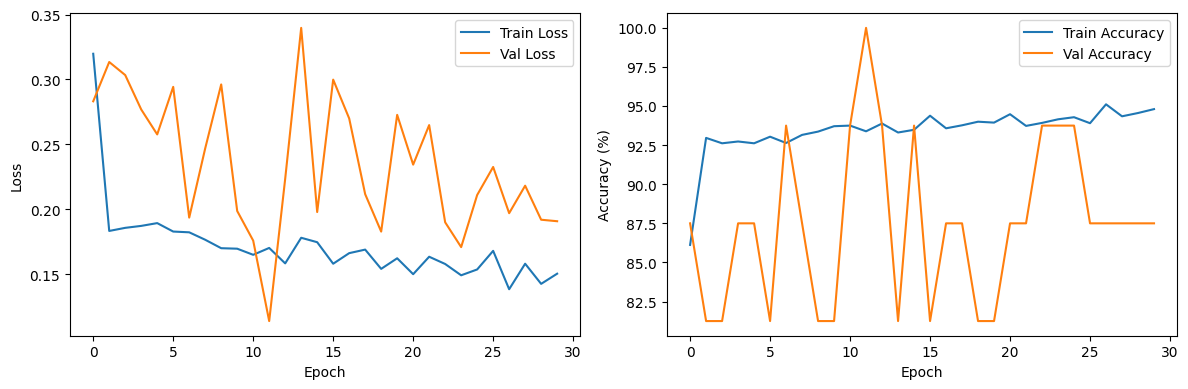

In [11]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.8, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 0.3080, Train Acc: 86.62%
Val Loss: 0.2836, Val Acc: 87.50%

Epoch 2/30:
Train Loss: 0.1731, Train Acc: 93.19%
Val Loss: 0.3146, Val Acc: 81.25%

Epoch 3/30:
Train Loss: 0.1428, Train Acc: 94.84%
Val Loss: 0.1465, Val Acc: 93.75%

Epoch 4/30:
Train Loss: 0.1360, Train Acc: 94.84%
Val Loss: 0.1227, Val Acc: 93.75%

Epoch 5/30:
Train Loss: 0.1276, Train Acc: 95.07%
Val Loss: 0.2599, Val Acc: 93.75%

Epoch 6/30:
Train Loss: 0.1254, Train Acc: 95.30%
Val Loss: 0.1918, Val Acc: 87.50%

Epoch 7/30:
Train Loss: 0.1280, Train Acc: 95.02%
Val Loss: 0.1799, Val Acc: 87.50%

Epoch 8/30:
Train Loss: 0.1218, Train Acc: 95.42%
Val Loss: 0.1679, Val Acc: 93.75%

Epoch 9/30:
Train Loss: 0.1238, Train Acc: 95.82%
Val Loss: 0.1519, Val Acc: 100.00%

Epoch 10/30:
Train Loss: 0.1242, Train Acc: 95.49%
Val Loss: 0.1265, Val Acc: 93.75%

Epoch 11/30:
Train Loss: 0.1249, Train Acc: 95.59%
Val Loss: 0.2143, Val Acc: 93.75%

Epoch 12/30:
Train Loss: 0.1074, Train Acc: 95.84%
Val Loss: 0

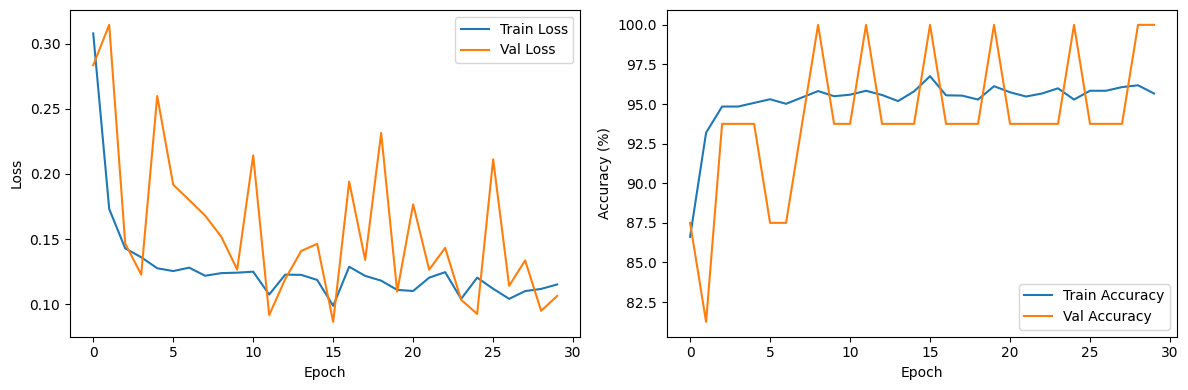

In [12]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.8, weight_decay=1e-4)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)